# Football IQ : FINAl Modelling



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

PROCESSED = "data/processed/"


## 1. Match Outcome Prediction

In [4]:
matches = pd.read_csv(PROCESSED + "clean_matches.csv", parse_dates=['Date'])
matches = matches.sort_values(['season','Date']).reset_index(drop=True)
print(matches.shape)
matches[['season','Date','home_team','away_team','result']].head()


(840, 46)


,season,Date,home_team,away_team,result
0,2021-2022,2021-08-13,Brentford,Arsenal,H
1,2021-2022,2021-08-14,Manchester Utd,Leeds United,H
2,2021-2022,2021-08-14,Leicester City,Wolves,H
3,2021-2022,2021-08-14,Burnley,Brighton,A
4,2021-2022,2021-08-14,Chelsea,Crystal Palace,H


### 1.1 Additional pre-match rolling features 

In [6]:
home_rows = matches[['season','Date','game_id','home_team','away_team','home_Corners','away_Corners','home_Fouls','away_Fouls']].copy()
home_rows.columns = ['season','Date','game_id','team','opponent','corners_for','corners_against','fouls_committed','fouls_against']
home_rows['is_home'] = 1

away_rows = matches[['season','Date','game_id','away_team','home_team','away_Corners','home_Corners','away_Fouls','home_Fouls']].copy()
away_rows.columns = ['season','Date','game_id','team','opponent','corners_for','corners_against','fouls_committed','fouls_against']
away_rows['is_home'] = 0

long_df = pd.concat([home_rows, away_rows], ignore_index=True).sort_values(['team','season','Date'])

for col in ['corners_for','corners_against','fouls_committed','fouls_against']:
    long_df[f'roll5_{col}'] = (
        long_df.groupby(['team','season'])[col]
        .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
    )

roll_cols = ['roll5_corners_for','roll5_corners_against','roll5_fouls_committed','roll5_fouls_against']
feat = long_df[['season','game_id','team','is_home'] + roll_cols]

home_feat = feat[feat['is_home']==1].drop(columns=['is_home','team']).rename(columns={c: f'home_{c}' for c in roll_cols})
away_feat = feat[feat['is_home']==0].drop(columns=['is_home','team']).rename(columns={c: f'away_{c}' for c in roll_cols})

matches = matches.merge(home_feat, on=['season','game_id'], how='left')
matches = matches.merge(away_feat, on=['season','game_id'], how='left')
matches.filter(like='roll5').head()


,home_roll5_points,home_roll5_goals_for,home_roll5_goals_against,away_roll5_points,away_roll5_goals_for,away_roll5_goals_against,home_roll5_corners_for,home_roll5_corners_against,home_roll5_fouls_committed,home_roll5_fouls_against,away_roll5_corners_for,away_roll5_corners_against,away_roll5_fouls_committed,away_roll5_fouls_against
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
def compute_elo(matches_df, k=20, home_adv=60):
    ratings = {}
    home_elo_pre = []
    away_elo_pre = []

    for _, row in matches_df.iterrows():
        h, a = row['home_team'], row['away_team']
        rh = ratings.get(h, 1500)
        ra = ratings.get(a, 1500)
        home_elo_pre.append(rh)
        away_elo_pre.append(ra)

        expected_h = 1 / (1 + 10 ** ((ra - (rh + home_adv)) / 400))
        actual_h = 1.0 if row['result']=='H' else (0.5 if row['result']=='D' else 0.0)

        ratings[h] = rh + k * (actual_h - expected_h)
        ratings[a] = ra + k * ((1-actual_h) - (1-expected_h))

    return home_elo_pre, away_elo_pre

matches['home_elo'], matches['away_elo'] = compute_elo(matches)
matches['elo_diff'] = matches['home_elo'] - matches['away_elo']
matches[['season','Date','home_team','away_team','home_elo','away_elo','result']].tail(10)


,season,Date,home_team,away_team,home_elo,away_elo,result
830,2023-2024,2023-10-07,Luton Town,Tottenham,1460.275203,1596.952758,A
831,2023-2024,2023-10-07,Everton,Bournemouth,1413.146947,1425.314840,H
832,2023-2024,2023-10-07,Manchester Utd,Brentford,1576.599543,1526.679143,H
833,2023-2024,2023-10-07,Burnley,Chelsea,1425.960967,1484.477923,A
834,2023-2024,2023-10-07,Fulham,Sheffield Utd,1496.229759,1449.208309,H
835,2023-2024,2023-10-07,Crystal Palace,Nott'ham Forest,1507.533887,1468.077657,D
836,2023-2024,2023-10-08,West Ham,Newcastle Utd,1496.823521,1601.398758,D
837,2023-2024,2023-10-08,Wolves,Aston Villa,1461.776388,1576.388960,D
838,2023-2024,2023-10-08,Brighton,Liverpool,1568.983868,1659.181241,D
839,2023-2024,2023-10-08,Arsenal,Manchester City,1660.388045,1727.829512,H


### 1.1c Head-to-head history



In [10]:
matches = matches.sort_values('Date').reset_index(drop=True)
h2h_feature = []

for idx, row in matches.iterrows():
    h, a, date = row['home_team'], row['away_team'], row['Date']
    prior = matches[(matches['Date'] < date) &
                     (((matches['home_team']==h) & (matches['away_team']==a)) |
                      ((matches['home_team']==a) & (matches['away_team']==h)))].tail(3)
    if len(prior) == 0:
        h2h_feature.append(np.nan)
        continue
    pts = []
    for _, p in prior.iterrows():
        if p['home_team'] == h:
            pts.append(3 if p['result']=='H' else (1 if p['result']=='D' else 0))
        else:
            pts.append(3 if p['result']=='A' else (1 if p['result']=='D' else 0))
    h2h_feature.append(np.mean(pts))

matches['h2h_home_points'] = h2h_feature
matches = matches.sort_values(['season','Date']).reset_index(drop=True)
print(f"Matches with head-to-head history available: {matches['h2h_home_points'].notna().sum()} / {len(matches)}")


Matches with head-to-head history available: 579 / 840


### 1.2 Feature set



In [12]:
feature_cols = [
    'home_roll5_points','home_roll5_goals_for','home_roll5_goals_against',
    'away_roll5_points','away_roll5_goals_for','away_roll5_goals_against',
    'home_roll5_corners_for','home_roll5_corners_against',
    'away_roll5_corners_for','away_roll5_corners_against',
    'home_roll5_fouls_committed','away_roll5_fouls_committed',
    'elo_diff','h2h_home_points',
]

matches['h2h_home_points'] = matches['h2h_home_points'].fillna(1.0)

form_cols_required = [c for c in feature_cols if c != 'h2h_home_points']
model_df = matches.dropna(subset=form_cols_required + ['result']).copy()
print(f"Rows available for modelling: {len(model_df)} (dropped {len(matches)-len(model_df)} early-season rows with no form history)")

X = model_df[feature_cols]
y = model_df['result']


Rows available for modelling: 810 (dropped 30 early-season rows with no form history)


### 1.3 Train split



In [14]:
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train)} matches ({model_df['Date'].iloc[0].date()} to {model_df['Date'].iloc[split_idx-1].date()})")
print(f"Test:  {len(X_test)} matches ({model_df['Date'].iloc[split_idx].date()} to {model_df['Date'].iloc[-1].date()})")


Train: 648 matches (2021-08-21 to 2023-04-08)
Test:  162 matches (2023-04-08 to 2023-10-08)


### 1.4 Baseline: always predict the most common class

In [16]:
baseline_pred = pd.Series([y_train.mode()[0]] * len(y_test))
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"Baseline ('always predict {y_train.mode()[0]}') accuracy: {baseline_acc:.1%}")


Baseline ('always predict H') accuracy: 46.9%


### 1.5 Train and compare three models

In [85]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# TimeSeriesSplit respects chronological order within cross-validation too --
# never trains on a fold that's chronologically after the validation fold
tscv = TimeSeriesSplit(n_splits=4)

param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=2000, class_weight='balanced'),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42, class_weight='balanced'),
        {'n_estimators': [200, 400], 'max_depth': [4, 6, 8], 'min_samples_leaf': [5, 10]}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='mlogloss', random_state=42),
        {'n_estimators': [150, 300], 'max_depth': [3, 4, 5], 'learning_rate': [0.03, 0.05, 0.1]}
    ),
}

results = {}
fitted_models = {}
for name, (estimator, grid) in param_grids.items():
    if name == 'Logistic Regression':
        search = GridSearchCV(estimator, grid, cv=tscv, scoring='accuracy', n_jobs=-1)
        search.fit(X_train_scaled, y_train)
        preds = search.predict(X_test_scaled)
    else:
        search = GridSearchCV(estimator, grid, cv=tscv, scoring='accuracy', n_jobs=-1)
        search.fit(X_train, y_train_enc)
        preds = le.inverse_transform(search.predict(X_test))

    fitted_models[name] = search.best_estimator_
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    print(f"{name}: best_params={search.best_params_}")
    print(f"  -> test accuracy={acc:.1%}, macro-F1={f1:.3f}")

models = fitted_models
results_df = pd.DataFrame(results).T
results_df


Logistic Regression: best_params={'C': 0.01}
  -> test accuracy=53.1%, macro-F1=0.462
Random Forest: best_params={'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 200}
  -> test accuracy=53.7%, macro-F1=0.476
XGBoost: best_params={'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 150}
  -> test accuracy=54.9%, macro-F1=0.415


,accuracy,precision,recall,f1
Logistic Regression,0.530864,0.459030,0.466313,0.461625
Random Forest,0.537037,0.475197,0.477400,0.475981
XGBoost,0.549383,0.412798,0.444627,0.414646


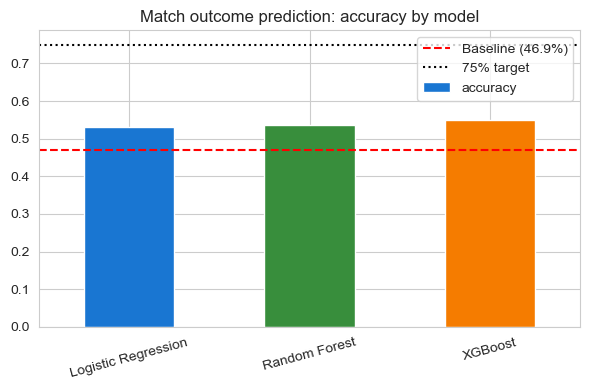

In [89]:
fig, ax = plt.subplots(figsize=(6,4))
results_df['accuracy'].plot(kind='bar', ax=ax, color=['#1976d2','#388e3c','#f57c00'])
ax.axhline(baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.1%})')
ax.axhline(0.75, color='black', linestyle=':', label='75% target')
ax.set_title('Match outcome prediction: accuracy by model')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 1.6 Confusion matrix — best model

Best model: XGBoost


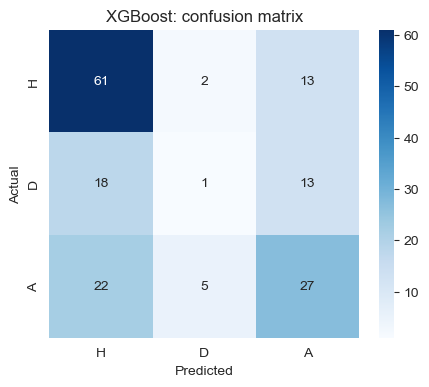

              precision    recall  f1-score   support

           A       0.51      0.50      0.50        54
           D       0.12      0.03      0.05        32
           H       0.60      0.80      0.69        76

    accuracy                           0.55       162
   macro avg       0.41      0.44      0.41       162
weighted avg       0.48      0.55      0.50       162



In [22]:
best_name = results_df['accuracy'].idxmax()
best_model = models[best_name]
print(f"Best model: {best_name}")

if best_name == 'Logistic Regression':
    best_preds = best_model.predict(X_test_scaled)
else:
    best_preds = le.inverse_transform(best_model.predict(X_test))

cm = confusion_matrix(y_test, best_preds, labels=['H','D','A'])
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['H','D','A'], yticklabels=['H','D','A'], cmap='Blues', ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{best_name}: confusion matrix')
plt.show()

print(classification_report(y_test, best_preds))


### 1.7 Feature importance

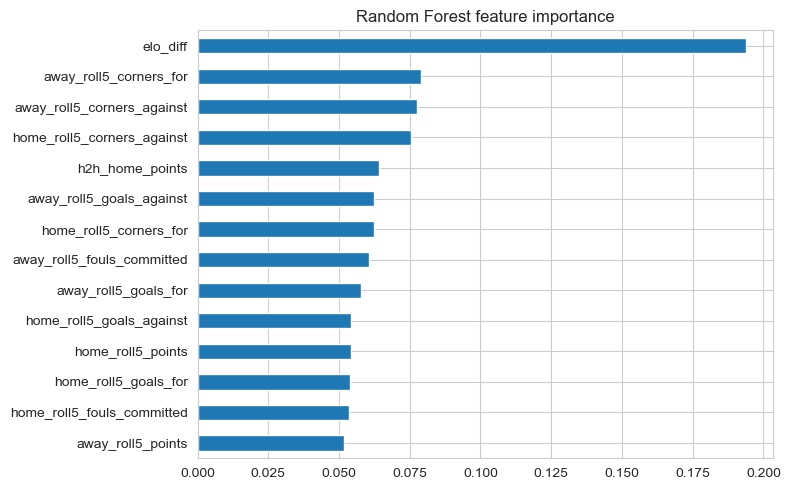

In [24]:
importances = pd.Series(models['Random Forest'].feature_importances_, index=feature_cols).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
importances.plot(kind='barh', ax=ax)
ax.set_title('Random Forest feature importance')
plt.tight_layout()
plt.show()


## 1.8 Interactive Match Predictor


In [93]:
from sklearn.ensemble import RandomForestRegressor

# Train corner/foul predictors on the same pre-match feature set and rows as the
# result classifier (model_df), so there's no leakage here either.
corner_target_home = model_df['home_Corners']
corner_target_away = model_df['away_Corners']
foul_target_home = model_df['home_Fouls']
foul_target_away = model_df['away_Fouls']

corner_model_home = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X, corner_target_home)
corner_model_away = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X, corner_target_away)
foul_model_home = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X, foul_target_home)
foul_model_away = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42).fit(X, foul_target_away)

print("Corner/foul regressors trained.")


Corner/foul regressors trained.


In [27]:
# Build a simple "current" ELO lookup: each team's most recent post-match rating
elo_events = pd.concat([
    matches[['Date','home_team','home_elo']].rename(columns={'home_team':'team','home_elo':'elo'}),
    matches[['Date','away_team','away_elo']].rename(columns={'away_team':'team','away_elo':'elo'}),
]).sort_values('Date')
final_elo = elo_events.groupby('team')['elo'].last().to_dict()


In [95]:
def get_recent_form(team, matches_df, n=5):
    home = matches_df[matches_df["home_team"] == team][
        ["Date","home_goals","away_goals","home_Corners","away_Corners","home_Fouls"]
    ].rename(columns={"home_goals":"goals_for","away_goals":"goals_against",
                       "home_Corners":"corners_for","away_Corners":"corners_against",
                       "home_Fouls":"fouls_committed"})
    away = matches_df[matches_df["away_team"] == team][
        ["Date","away_goals","home_goals","away_Corners","home_Corners","away_Fouls"]
    ].rename(columns={"away_goals":"goals_for","home_goals":"goals_against",
                       "away_Corners":"corners_for","home_Corners":"corners_against",
                       "away_Fouls":"fouls_committed"})
    games = pd.concat([home, away], ignore_index=True).sort_values("Date", ascending=False).head(n)
    if len(games) == 0:
        return dict(points=1.0, goals_for=1.0, goals_against=1.0, corners_for=5.0, corners_against=5.0, fouls_committed=10.0)
    pts = np.select([games["goals_for"]>games["goals_against"], games["goals_for"]==games["goals_against"]], [3,1], default=0)
    return dict(points=pts.mean(), goals_for=games["goals_for"].mean(), goals_against=games["goals_against"].mean(),
                corners_for=games["corners_for"].mean(), corners_against=games["corners_against"].mean(),
                fouls_committed=games["fouls_committed"].mean())

def get_h2h_live(home_team, away_team, matches_df, n=3):
    prior = matches_df[((matches_df["home_team"]==home_team)&(matches_df["away_team"]==away_team)) |
                        ((matches_df["home_team"]==away_team)&(matches_df["away_team"]==home_team))
                       ].sort_values("Date", ascending=False).head(n)
    if len(prior)==0: return 1.0
    pts=[]
    for _, p in prior.iterrows():
        if p["home_team"]==home_team: pts.append(3 if p["result"]=="H" else (1 if p["result"]=="D" else 0))
        else: pts.append(3 if p["result"]=="A" else (1 if p["result"]=="D" else 0))
    return float(np.mean(pts))

def predict_match_live(home_team, away_team):
    hf, af = get_recent_form(home_team, matches), get_recent_form(away_team, matches)
    h_elo, a_elo = final_elo.get(home_team, 1500), final_elo.get(away_team, 1500)
    h2h = get_h2h_live(home_team, away_team, matches)

    row = pd.DataFrame([{
        "home_roll5_points": hf["points"], "home_roll5_goals_for": hf["goals_for"], "home_roll5_goals_against": hf["goals_against"],
        "away_roll5_points": af["points"], "away_roll5_goals_for": af["goals_for"], "away_roll5_goals_against": af["goals_against"],
        "home_roll5_corners_for": hf["corners_for"], "home_roll5_corners_against": hf["corners_against"],
        "away_roll5_corners_for": af["corners_for"], "away_roll5_corners_against": af["corners_against"],
        "home_roll5_fouls_committed": hf["fouls_committed"], "away_roll5_fouls_committed": af["fouls_committed"],
        "elo_diff": h_elo - a_elo, "h2h_home_points": h2h,
    }])[feature_cols]

    best_clf = models[best_name]
    if best_name == "Logistic Regression":
        proba = best_clf.predict_proba(scaler.transform(row))[0]
    else:
        proba = best_clf.predict_proba(row)[0]
    proba_map = dict(zip(le.classes_, proba))

    pred_home_corners = corner_model_home.predict(row)[0]
    pred_away_corners = corner_model_away.predict(row)[0]
    pred_home_fouls = foul_model_home.predict(row)[0]
    pred_away_fouls = foul_model_away.predict(row)[0]

    return proba_map, pred_home_corners, pred_away_corners, pred_home_fouls, pred_away_fouls, h_elo, a_elo

def show_prediction(home_team, away_team):
    proba_map, hc, ac, hf_, af_, h_elo, a_elo = predict_match_live(home_team, away_team)
    p_h, p_d, p_a = proba_map.get("H",0), proba_map.get("D",0), proba_map.get("A",0)
    most_likely = max(proba_map, key=proba_map.get)
    label = {"H": f"{home_team} Win", "D": "Draw", "A": f"{away_team} Win"}[most_likely]

    print("="*60)
    print(f"  {home_team}  vs  {away_team}")
    print("="*60)
    print(f"  ELO ratings:        {home_team} {h_elo:.0f}   |   {away_team} {a_elo:.0f}")
    print("-"*60)
    print(f"  {home_team} Win : {p_h:6.1%}")
    print(f"  Draw            : {p_d:6.1%}")
    print(f"  {away_team} Win : {p_a:6.1%}")
    print("-"*60)
    print(f"  Predicted outcome: {label}  ({proba_map[most_likely]:.1%} confidence)")
    print("-"*60)
    print(f"  Predicted corners:  {home_team} {hc:.1f}   |   {away_team} {ac:.1f}")
    print(f"  Predicted fouls:    {home_team} {hf_:.1f}   |   {away_team} {af_:.1f}")
    print("="*60)


In [ ]:
all_teams_list = sorted(set(matches['home_team']) | set(matches['away_team']))
print("Available teams:", ", ".join(all_teams_list))
print()

def prompt_team(label):
    while True:
        name = input(f"Enter {label} team: ").strip()
        # case-insensitive match against the real team names
        match = next((t for t in all_teams_list if t.lower() == name.lower()), None)
        if match:
            return match
        print(f'  "{name}" not recognised. Please type it exactly as shown in the list above and try again.')

HOME_TEAM = prompt_team("HOME")
AWAY_TEAM = prompt_team("AWAY")

show_prediction(HOME_TEAM, AWAY_TEAM)


Available teams: Arsenal, Aston Villa, Bournemouth, Brentford, Brighton, Burnley, Chelsea, Crystal Palace, Everton, Fulham, Leeds United, Leicester City, Liverpool, Luton Town, Manchester City, Manchester Utd, Newcastle Utd, Norwich City, Nott'ham Forest, Sheffield Utd, Southampton, Tottenham, Watford, West Ham, Wolves



## 2. Player-Style Clustering (K-Means)



In [77]:
players = pd.read_csv(PROCESSED + "clean_players_with_value.csv")
print(players.shape)

# aggregate per player-season: mean per-90 rate stats, weighted implicitly by
# only keeping players with a reasonable sample of minutes
p90_cols = ['Gls_p90','Ast_p90','Sh_p90','SoT_p90','Tkl_p90','Int_p90','Touches_p90','PrgP_p90','PrgC_p90']

player_season = (players.groupby(['Player','season','Pos'])
                  .agg(total_minutes=('Min','sum'), **{c: (c,'mean') for c in p90_cols})
                  .reset_index())

# require a meaningful sample -- at least 450 minutes (~5 full matches)
player_season = player_season[player_season['total_minutes'] >= 450].copy()
print(f"Player-seasons with >=450 minutes: {len(player_season)}")
player_season.head()


(24239, 68)
Player-seasons with >=450 minutes: 905


,Player,season,Pos,total_minutes,Gls_p90,Ast_p90,Sh_p90,SoT_p90,Tkl_p90,Int_p90,Touches_p90,PrgP_p90,PrgC_p90
4,Aaron Cresswell,2021-2022,LB,2276,0.076923,0.076923,0.673077,0.115385,0.884615,1.119505,75.901099,7.076923,2.171703
8,Aaron Cresswell,2022-2023,LB,1965,0.000000,0.040000,0.280449,0.040000,0.841348,2.196971,59.733919,5.395090,1.405096
10,Aaron Hickey,2022-2023,RB,1473,0.000000,0.051136,0.677345,0.116962,1.653933,0.706738,49.163506,3.785739,2.171656
24,Aaron Lennon,2021-2022,RM,943,0.077787,0.000000,0.348974,0.077787,2.238838,0.390974,33.436171,0.792937,2.438280
28,Aaron Ramsdale,2021-2022,GK,3060,0.000000,0.000000,0.000000,0.000000,0.058824,0.000000,37.000000,0.029412,0.000000


### 2.1 Exclude goalkeepers


In [36]:
player_season = player_season[player_season['Pos'] != 'GK'].copy()
print(f"After excluding GKs: {len(player_season)}")


After excluding GKs: 833


### 2.2 Standardise features

In [38]:
X_cluster = player_season[p90_cols]
scaler2 = StandardScaler()
X_cluster_scaled = scaler2.fit_transform(X_cluster)


### 2.3 Choose K: Elbow method + Silhouette score

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Window

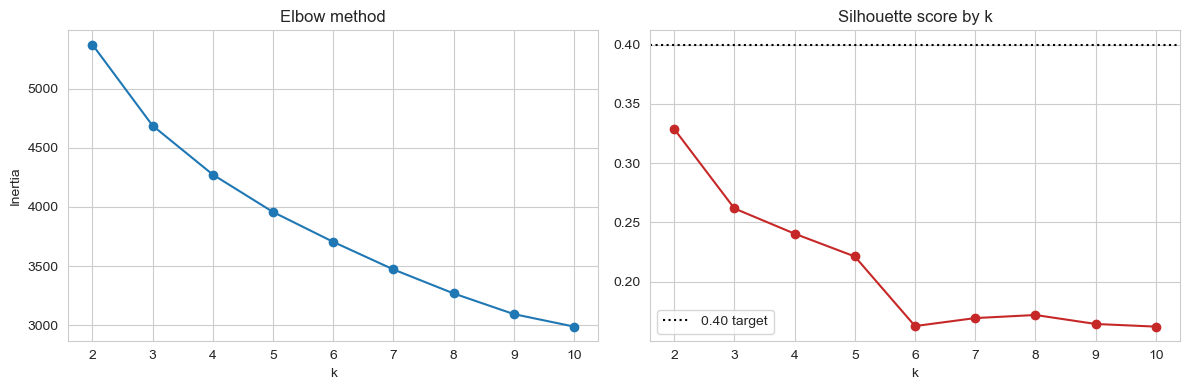

Best k by silhouette score: 2 (score=0.329)


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(K_range), silhouettes, marker='o', color='#c62828')
axes[1].axhline(0.40, color='black', linestyle=':', label='0.40 target')
axes[1].set_title('Silhouette score by k')
axes[1].set_xlabel('k')
axes[1].legend()
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette score: {best_k} (score={max(silhouettes):.3f})")


### 2.4 Fit final K-Means and interpret clusters

In [43]:
# k=2 scores best statistically but is too coarse to be a useful "playing style"
# breakdown (it mostly just separates high-minutes vs low-minutes players).
# We force k=5 instead -- a common, interpretable number of outfield role groups
# (e.g. ball-winners, deep playmakers, box-to-box, wide creators, advanced forwards) --
# and report its silhouette score honestly alongside the statistically "best" k.
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
player_season['cluster'] = kmeans.fit_predict(X_cluster_scaled)

forced_silhouette = silhouette_score(X_cluster_scaled, player_season['cluster'])
print(f"k={final_k} silhouette score: {forced_silhouette:.3f}  (vs k={best_k} statistically-best score: {max(silhouettes):.3f})")

cluster_profile = player_season.groupby('cluster')[p90_cols].mean().round(2)
cluster_profile['n_players'] = player_season['cluster'].value_counts()
cluster_profile


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


k=5 silhouette score: 0.221  (vs k=2 statistically-best score: 0.329)


,Gls_p90,Ast_p90,Sh_p90,SoT_p90,Tkl_p90,Int_p90,Touches_p90,PrgP_p90,PrgC_p90,n_players
cluster,,,,,,,,,,
0,0.04,0.04,0.60,0.16,1.99,1.28,59.15,3.10,0.99,380
1,0.17,0.82,2.28,0.60,2.11,0.87,78.20,7.26,4.09,23
2,0.75,0.19,3.28,1.47,1.05,0.33,43.26,2.77,2.70,60
3,0.21,0.16,2.18,0.73,1.19,0.43,44.13,2.76,2.70,198
4,0.09,0.10,1.09,0.29,2.14,0.97,80.67,6.52,1.95,172


In [44]:
# Most representative / best-known players per cluster, to sanity-check football sense
for c in sorted(player_season['cluster'].unique()):
    top_players = (player_season[player_season['cluster']==c]
                    .sort_values('total_minutes', ascending=False)['Player'].head(5).tolist())
    print(f"Cluster {c} (n={sum(player_season['cluster']==c)}): {top_players}")


Cluster 0 (n=380): ['James Tarkowski', 'Gabriel Dos Santos', 'Conor Coady', 'Marc Guéhi', 'Pontus Jansson']
Cluster 1 (n=23): ["N'Golo Kanté", 'Reece James', 'Allan Saint-Maximin', 'Kevin De Bruyne', 'Nemanja Matić']
Cluster 2 (n=60): ['Harry Kane', 'Harry Kane', 'Ivan Toney', 'Erling Haaland', 'Mohamed Salah']
Cluster 3 (n=198): ['Teemu Pukki', 'Ivan Toney', 'Martin Ødegaard', 'Michail Antonio', 'Chris Wood']
Cluster 4 (n=172): ['Kieran Trippier', 'Lewis Dunk', 'Virgil van Dijk', 'Antonio Rüdiger', 'Trent Alexander-Arnold']


### 2.5 Visualise clusters (PCA to 2D)

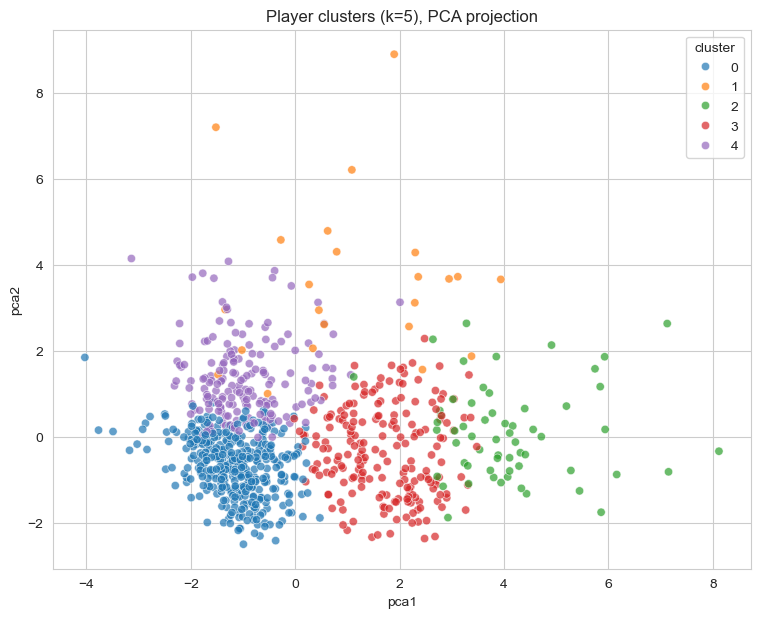

Variance explained by 2 PCA components: 58.0%


In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_cluster_scaled)
player_season['pca1'] = coords[:,0]
player_season['pca2'] = coords[:,1]

fig, ax = plt.subplots(figsize=(9,7))
sns.scatterplot(data=player_season, x='pca1', y='pca2', hue='cluster', palette='tab10', alpha=0.7, ax=ax)
ax.set_title(f'Player clusters (k={final_k}), PCA projection')
plt.show()

print(f"Variance explained by 2 PCA components: {pca.explained_variance_ratio_.sum():.1%}")


### 2.6 Save results

In [48]:
player_season.to_csv(PROCESSED + "player_clusters.csv", index=False)
print("Saved:", PROCESSED + "player_clusters.csv")


Saved: data/processed/player_clusters.csv
